# Plotting GPR data
The data has already been preprocessed by Dr. Christophe Ogier & Dr. Ilaria Santin. Several steps have been conducted:

1. Filtering
2. Bed picking
3. ...

In [1]:
import sys

# Add project root to Python path
project_root = '/Users/janoschbeer/Library/Mobile Documents/com~apple~CloudDocs/PhD/projects/asses_swiss_gl_therm_regimes'
if project_root not in sys.path:
    sys.path.insert(0, project_root)

# Cell 1: Imports and inputs
import os
import geopandas as gpd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gpr_processing as gpr
import gpr_plotting as gprp
import rasterio
import cmcrameri.cm as cmc
from processing.thermistor_processing import *
from rasterio.plot import show as rioshow

pixel_size = 20.0    # meters
interp_method = 'linear'  # 'linear' | 'cubic' | 'nearest'

### Set up paths

In [2]:
root_dir = "/Users/janoschbeer/Library/Mobile Documents/com~apple~CloudDocs/PhD/data/fieldwork_data/THERMAP_2024_2025/gpr/20250515_Alphubel"
project_dir = "/Users/janoschbeer/Library/Mobile Documents/com~apple~CloudDocs/PhD/projects/asses_swiss_gl_therm_regimes"

# List your TXT files
txt_files = [
    root_dir + "/bed picks_south/20060101_GPR_picks_south.txt" # Alphubel south
]

# Optional local orthophoto (GeoTIFF). Leave None to use online basemap instead.
ortho_path = None  # e.g., os.path.join(root_dir, "orthophoto.tif")

In [3]:
points = gpr.load_points_from_txt(txt_files, epsg=2056, drop_duplicates=True, aggregate_duplicates='mean')
coverage = gpr.make_coverage_polygon(points, method='convex', buffer_m=0.0)  # avoids optimizealpha
print(points.shape, coverage.crs, coverage.geometry.iloc[0].geom_type)

(7424, 4) EPSG:2056 Polygon


### Download Orhophotos from Swisstopo

In [4]:
# set download dir
ortho_dir = project_dir + "/products/figures/gpr_figures/ice_thickness_maps/"

# Download orthophoto (swisstopo WMS) for coverage area, but with extra margin
ortho_buffer_m = 200  # increase to cover more area than the heatmap
bbox = gpr.bbox_from_gdf(coverage, buffer_m=ortho_buffer_m)  # add margin around coverage

out_ortho = os.path.join(ortho_dir, "alphubel_orthophoto.tif")
_, ortho_transform, ortho_crs = gpr.download_swisstopo_orthophoto(
    bbox, out_ortho, crs_epsg=2056, pixel_size=0.5,  # 1 m/px; use 0.5 for finer (bigger download)
    layer="ch.swisstopo.swissimage", fmt="image/jpeg"
)
print("Orthophoto saved:", out_ortho)

Orthophoto saved: /Users/janoschbeer/Library/Mobile Documents/com~apple~CloudDocs/PhD/projects/asses_swiss_gl_therm_regimes/products/figures/gpr_figures/ice_thickness_maps/alphubel_orthophoto.tif


### Interpolate GPR ice thickness to grid

In [5]:
# Interpolation settings
pixel_size = 3.0    # meters (was 20.0)
interp_method = 'linear'  # or 'cubic'|'nearest'

# Interpolate GPR thickness to a grid (returns grid and its geotransform)
grid, grid_transform, grid_crs = gpr.interpolate_to_grid(
    points, value_col='thickness',
    pixel_size=pixel_size, method=interp_method,
    polygon_mask=coverage, padding=0.0
)
print("Grid shape:", grid.shape)

Grid shape: (69, 50)


### Load other data for map

In [6]:
# GPR line tracks (force LV95 / EPSG:2056)
gpr_lines_path = root_dir + "/bed picks_south/20060101_GPR_picks.shp"
gpr_lines = gpd.read_file(gpr_lines_path)

# Always assign EPSG:2056 (LV95), even if CRS is missing or wrong in the file
gpr_lines = gpr_lines.set_crs(epsg=2056, allow_override=True)

print("GPR lines:", len(gpr_lines), "features; CRS:", gpr_lines.crs)

# Load latest borehole positions
bh_csv = root_dir + "/../../icetemperature_data/thermistor_settings/thermistor_coordinates.csv"
keep_bh = ["AH1G", "AH2G", "AH3G", "AH4TT", "AH5TT", "AH6TT"]
boreholes, bh_missing = gpr.load_borehole_positions(bh_csv, keep_names=keep_bh)

# Download SwissALTI3D DEM to generate elevation contours
from glob import glob
dem_tiles = sorted(glob(os.path.join(
    "/Users/janoschbeer/Library/Mobile Documents/com~apple~CloudDocs/PhD/data/fieldwork_data/THERMAP_2024_2025/borehole_locations_displacement_rates/dems/alphubel", "*.tif")
))
assert len(dem_tiles) > 0, "No DEM tiles found in borehole_locations_displacement_rates/dems/alphubel/*.tif"


GPR lines: 1 features; CRS: EPSG:2056


In [7]:
boreholes

,name,date,x,y,geometry
16,AH1G,06.08.25,2633226.81,1100604.12,POINT (2633226.81 1100604.12)
17,AH2G,06.08.25,"2633183,50","1100551,82",POINT (2633183.5 1100551.82)
18,AH3G,06.08.25,"2633245,17","1100634,30",POINT (2633245.17 1100634.3)
19,AH4TT,06.08.25,"2633203,23","1100579,67",POINT (2633203.23 1100579.67)
20,AH5TT,21.08.24,"2633249,72","1100537,76",POINT (2633249.72 1100537.76)
22,AH6TT,05.08.25,"2633251,63","1100564,25",POINT (2633251.63 1100564.25)


## Plot Alphubel ice thickness heatmap

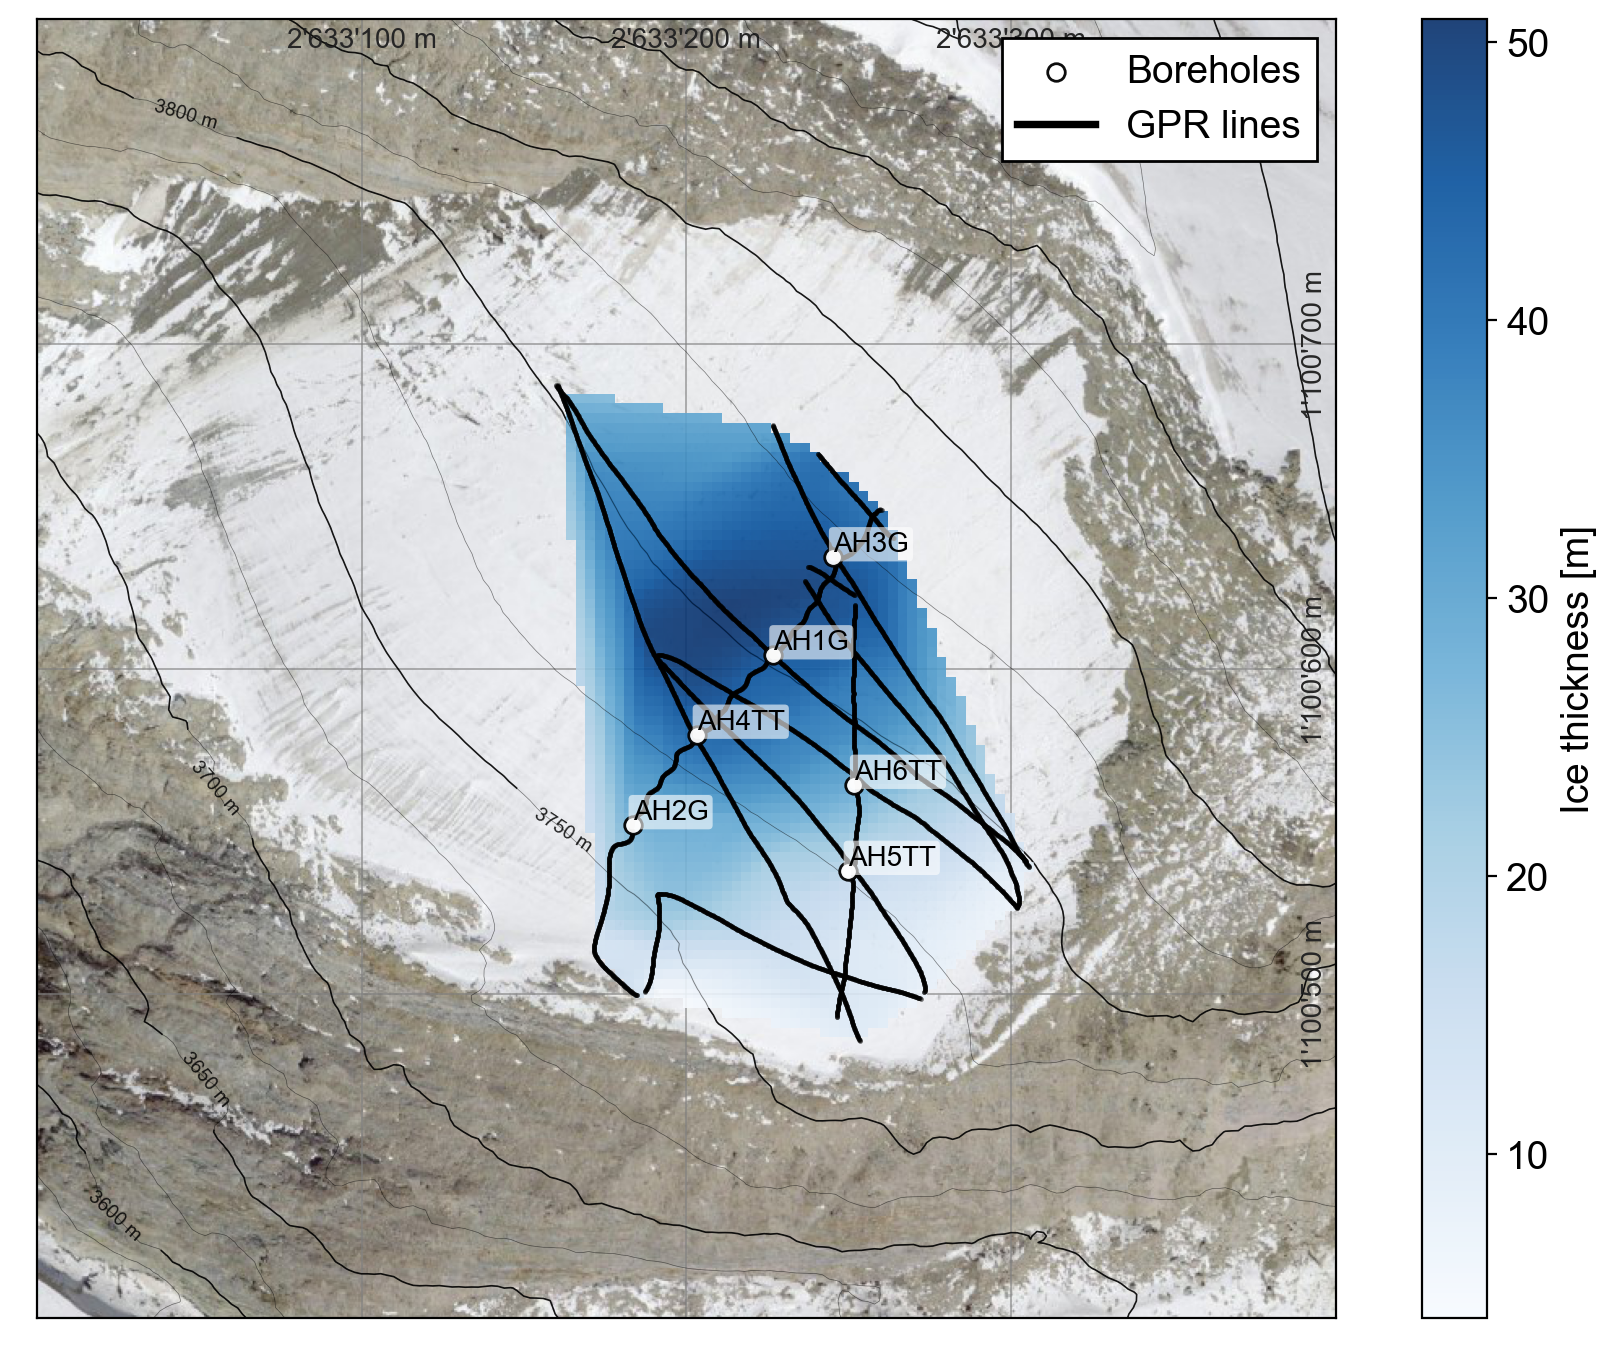

In [8]:
with rasterio.open(out_ortho) as src:
    fig, ax = plt.subplots(figsize=(9,7), dpi=200)
    rioshow(src, ax=ax)

    # Colormap for ice thickness from cairomakie/julia (blueish)
    cmap_blue = gprp.cairomakie_cmap("Blues", n=256, reverse=False)

    # Ice thickness
    im, extent = gprp.imshow_grid(ax, grid, grid_transform, cmap=cmap_blue, alpha=0.9)

    # Elevation contours from local DEM tiles (mosaic + clip on the fly)
    gprp.plot_dem_contours_from_tiles(
        ax, dem_tiles,
        bbox=bbox,
        pixel_size=2.0,
        minor_step=25.0, major_step=50.0,
        label=True, label_fmt="%.0f m",
        minor_kwargs={'linewidths':0.25, 'colors':'k', 'alpha':0.5},
        major_kwargs={'linewidths':0.6,  'colors':'k', 'alpha':0.85},
        zorder_minor=5, zorder_major=2,
    )

    # GPR samples as tiny dots
    gprp.draw_gpr_line_points(ax, gpr_lines, size=3, color='k', alpha=0.5, zorder=6)

    # Plot boreholes as simple, larger dots (no outline)
    if not boreholes.empty:
        ax.scatter(
            boreholes.geometry.x, boreholes.geometry.y,
            s=40, marker='o', color='white', edgecolors='black',
            linewidths=1, alpha=0.95, zorder=7, label='Boreholes'
        )
        # Optional labels
        for _, r in boreholes.iterrows():
            ax.text(r.geometry.x, r.geometry.y, r['name'],
                    fontsize=10, color='k', ha='left', va='bottom',
                    bbox=dict(boxstyle='round,pad=0.15', fc='white', ec='none', alpha=0.6),
                    zorder=8)

    # Legend handle for GPR lines
    ax.plot([], [], color='k', linewidth=0.4, label='GPR lines')

    ax.tick_params(axis='both', which='both', length=0, width=0,
                labelbottom=False, labeltop=False, labelleft=False, labelright=False)

    cb = fig.colorbar(im, ax=ax, label='Ice thickness [m]')

    # Zoom to bbox (EPSG:2056)
    x0, x1 = 2633000, 2633400
    y0, y1 = 1100400, 1100800
    ax.set_xlim(x0, x1); ax.set_ylim(y0, y1)

    # Axes formatting: set major tick spacing and draw subtle grid lines
    gprp.format_axes_coords(ax, x_step=100, y_step=100, thousands='apostrophe', unit='m', decimals=0)
    ax.grid(True, which='major', color='0.5', linewidth=0.6, alpha=0.7)

    # Put small coordinate labels inside, on the grid lines (Swiss-map style)
    gprp.annotate_coordinates_on_grid(ax, sides=('top','right'), thousands='apostrophe',
                                     unit='m', decimals=0, fontsize=10, color='0.15')

    # Final formatting and save
    gprp.format_plot(ax=ax, legend_loc='upper right', cbar=cb, y_tick_rotation=90, x_tick_rotation=0)

    out_fig = ortho_dir + "alphubel_gpr_ice_thickness_map.png"
    plt.savefig(out_fig, dpi=300, bbox_inches='tight', pad_inches=0.1)

## Plot Alphubel ice thickness profile

In [9]:
# Build a profile table (use the raw TXT files)
df_all = pd.concat([gpr.read_thickness_txt(p) for p in txt_files], ignore_index=True)

# Choose a profile id present in df_all['profile'] (e.g., 12)
prof_id = 4
prof = gpr.extract_profile_table(df_all, prof_id, order_method="pca")

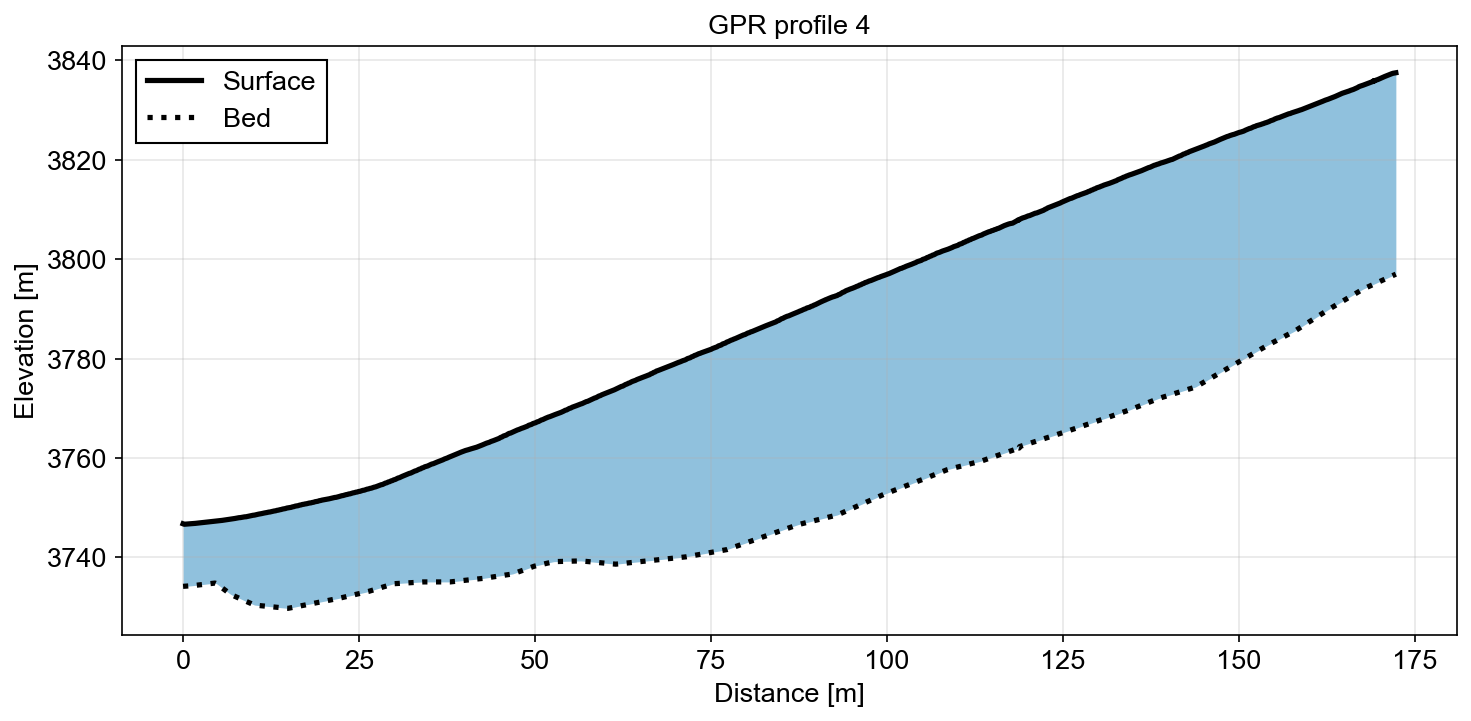

In [10]:
# Plot cross-section
fig, ax = gprp.plot_thickness_profile(prof, title=f"GPR profile {prof_id}")

## Plot Alphubel ice thickness & interpolated englacial temperature profile

### Set directions to thermistor data

In [11]:
# set chain icetemp data dir
gp_icetemp_dir = "/Users/janoschbeer/Library/Mobile Documents/com~apple~CloudDocs/PhD/data/fieldwork_data/THERMAP_2024_2025/icetemperature_data/thermistor_chains/temperature_data/"

# set path to current depth file
depth_AH1G = gp_icetemp_dir + "../../thermistor_settings/thermistor_settings_ah1g.csv"
depth_AH2G = gp_icetemp_dir + "../../thermistor_settings/thermistor_settings_ah2g.csv"
depth_AH3G = gp_icetemp_dir + "../../thermistor_settings/thermistor_settings_ah3g.csv"

# set chain data dir
A551FE_dir = gp_icetemp_dir + "A551FE/raw/A551FE_20250805133507.csv" # AH1G
A55204_dir = gp_icetemp_dir + "A55204/raw/" # AH2G
A55205_dir = gp_icetemp_dir + "A55205/raw/" # AH3G
A551FD_dir = gp_icetemp_dir + "A551FD/raw/" # HL1G
A55203_dir = gp_icetemp_dir + "A55203/raw/" # HL2G
A55200_dir = gp_icetemp_dir + "A55200/raw/" # HL3G
A55201_dir = gp_icetemp_dir + "A55201/raw/A55201_20250819105833.csv" # CH1G
A55202_dir = gp_icetemp_dir + "A55202/raw/A55202_20250819111557.csv" # CH2G

# generate a thermistor data object
AH1G = ThermistorData(A551FE_dir, ",", depth_AH1G)
AH2G = ThermistorData(A55204_dir, ",", depth_AH2G)
AH3G = ThermistorData(A55205_dir, ",", depth_AH3G)

# read chain temperature offsets from CSV file
offsets_path = "/Users/janoschbeer/Library/Mobile Documents/com~apple~CloudDocs/PhD/projects/asses_swiss_gl_therm_regimes/products/figures/thermistor_calibration/corrected_chain_offsets.csv"
corrected_offsets = pd.read_csv(offsets_path, index_col='chain')


In [12]:
corrected_offsets.loc["A551FE"]

#1    -0.020367
#2    -0.181417
#3    -0.019492
#4     0.117354
#5    -0.074464
#6     0.016296
#7     0.001848
#8     0.063762
#9    -0.006345
#10   -0.162618
Name: A551FE, dtype: float64

In [13]:
# Step 1. get coordinates for each borehole
bh_csv = root_dir + "/../../icetemperature_data/thermistor_settings/thermistor_coordinates.csv"
keep_bh = ["AH1G", "AH2G", "AH3G", "AH4TT", "AH5TT", "AH6TT"]
borehole_coordinates, bh_missing = gpr.load_borehole_positions(bh_csv, keep_names=keep_bh)

# Step 2. get temperature data for each borehole and thermistor
AH1G_data = AH1G.get_chain_data_with_offsets(snapshot_day='20250728', offsets=corrected_offsets.loc["A551FE"])
# AH2G.get_chain_data_with_offsets(snapshot_day='20250728', offsets=corrected_offsets)
# AH3G.get_chain_data_with_offsets(snapshot_day='20250728', offsets=corrected_offsets)

# step 3. get depths for each thermistor in the borehole
AH1G_depths = read_thermistor_depths(depth_AH1G)

In [14]:
borehole_coordinates

,name,date,x,y,geometry
16,AH1G,06.08.25,2633226.81,1100604.12,POINT (2633226.81 1100604.12)
17,AH2G,06.08.25,"2633183,50","1100551,82",POINT (2633183.5 1100551.82)
18,AH3G,06.08.25,"2633245,17","1100634,30",POINT (2633245.17 1100634.3)
19,AH4TT,06.08.25,"2633203,23","1100579,67",POINT (2633203.23 1100579.67)
20,AH5TT,21.08.24,"2633249,72","1100537,76",POINT (2633249.72 1100537.76)
22,AH6TT,05.08.25,"2633251,63","1100564,25",POINT (2633251.63 1100564.25)


In [15]:
# Prepare temperature series for 2025-07-28
ah1g_20250728 = AH1G_data[AH1G_data['TIME'].dt.date == pd.to_datetime('2025-07-28').date()]
ah1g_temp_series = ah1g_20250728.mean(numeric_only=True)

# Prepare dicts for the function
temp_data_dict = {'AH1G': ah1g_temp_series}
depth_dict = {'AH1G': AH1G_depths}

In [16]:
temp_data_dict

{'AH1G': #1          3.770668
 #2          3.391335
 #3          3.671322
 #4          3.978568
 #5          3.538232
 #6          3.792923
 #7          3.711539
 #8          3.866785
 #9          3.715123
 #10         3.402303
 HK-BAT:V    3.356944
 dtype: float64}

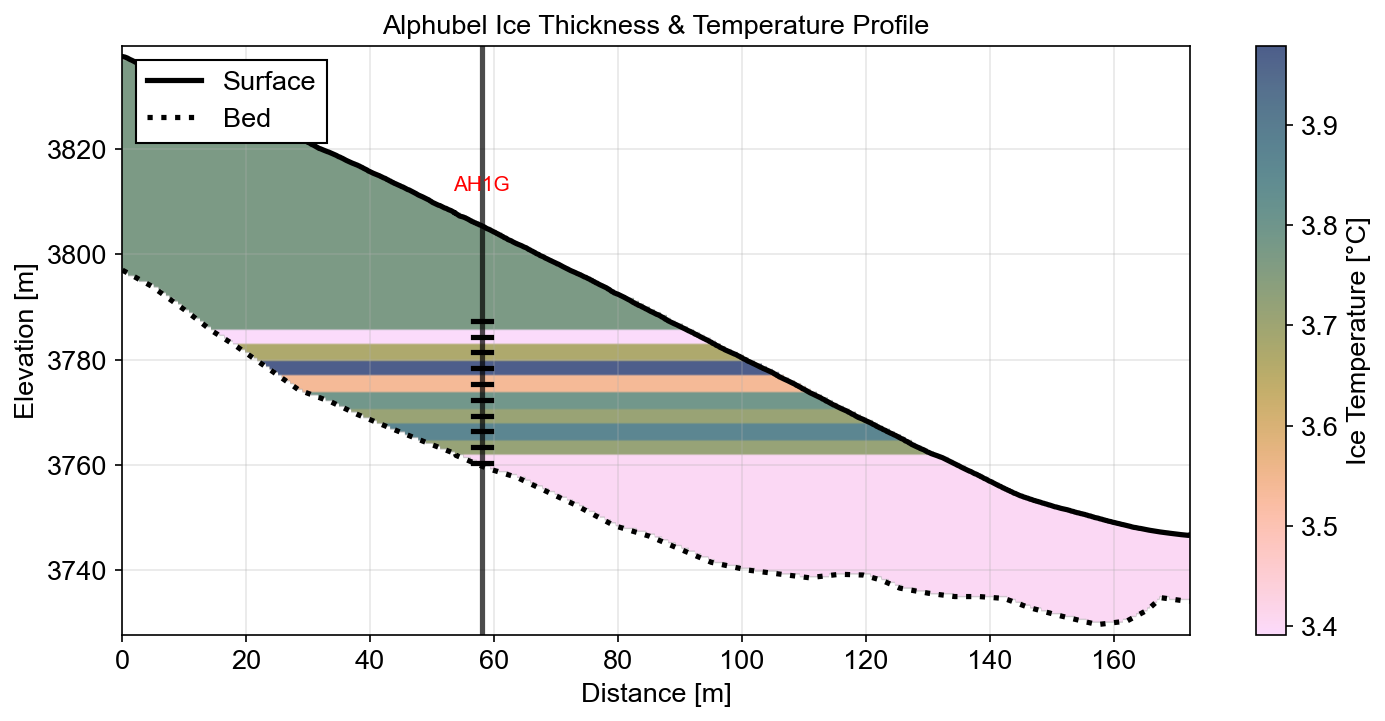

In [17]:
fig, ax = gprp.plot_thickness_icetemp_heatmap(
    profile_df=prof,
    borehole_coords_df=borehole_coordinates,
    temp_data_dict=temp_data_dict,
    depth_dict=depth_dict,
    title="Alphubel Ice Thickness & Temperature Profile",
    flip='false'  # or True/False
)